In [1]:
import pandas as pd
import numpy as np
import time
from time import time as t

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras import regularizers

2026-04-08 08:55:38.493696: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1775638538.731477      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1775638538.801428      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1775638539.317498      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775638539.317540      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1775638539.317543      55 computation_placer.cc:177] computation placer alr

In [2]:
df = pd.read_csv('/kaggle/input/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows/imdb_top_1000.csv')
print(df.shape)
df.head()

(1000, 16)


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [3]:

print(df.columns.tolist())
print(df.dtypes)

['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']
Poster_Link       object
Series_Title      object
Released_Year     object
Certificate       object
Runtime           object
Genre             object
IMDB_Rating      float64
Overview          object
Meta_score       float64
Director          object
Star1             object
Star2             object
Star3             object
Star4             object
No_of_Votes        int64
Gross             object
dtype: object


In [4]:

df = df[['Overview', 'IMDB_Rating']].dropna()

df['sentiment'] = df['IMDB_Rating'].apply(lambda x: 'positive' if x >= 8.0 else 'negative')

df['Overview'] = df['Overview'].astype(str)

print(df['sentiment'].value_counts())
df.head()

sentiment
negative    537
positive    463
Name: count, dtype: int64


,Overview,IMDB_Rating,sentiment
0,Two imprisoned men bond over a number of years...,9.3,positive
1,An organized crime dynasty's aging patriarch t...,9.2,positive
2,When the menace known as the Joker wreaks havo...,9.0,positive
3,The early life and career of Vito Corleone in ...,9.0,positive
4,A jury holdout attempts to prevent a miscarria...,9.0,positive


In [5]:
# Encode labels
le = LabelEncoder()
df['label'] = le.fit_transform(df['sentiment'])
print("Classes:", le.classes_)

# Tokenization
tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(df['Overview'])

sequences = tokenizer.texts_to_sequences(df['Overview'])
X = pad_sequences(sequences, maxlen=100)

y = df['label'].values

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Train size: {X_train.shape}, Test size: {X_test.shape}")
print("Data ready")

Classes: ['negative' 'positive']
Train size: (800, 100), Test size: (200, 100)
Data ready


In [6]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

lr_reduce = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=1,
    min_lr=1e-5
)

In [7]:
lstm_model = Sequential([
    Embedding(5000, 64, input_length=100),
    LSTM(64),
    Dense(32, activation='relu',
          kernel_regularizer=regularizers.l2(0.001)),
    Dense(len(le.classes_), activation='softmax')
])

lstm_model.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1775638560.367083      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1775638560.372921      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [8]:
start = t()

history_lstm = lstm_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop, lr_reduce],
    verbose=1
)

end = t()
lstm_time = end - start

print("LSTM Training Time:", lstm_time)

Epoch 1/10


I0000 00:00:1775638563.498986     125 cuda_dnn.cc:529] Loaded cuDNN version 91002


10/10 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.5192 - loss: 0.7334 - val_accuracy: 0.5125 - val_loss: 0.7290 - learning_rate: 0.0010
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5456 - loss: 0.7208 - val_accuracy: 0.5125 - val_loss: 0.7258 - learning_rate: 0.0010
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.5296 - loss: 0.7056 - val_accuracy: 0.5125 - val_loss: 0.7268 - learning_rate: 0.0010
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6269 - loss: 0.6510 - val_accuracy: 0.5500 - val_loss: 0.7145 - learning_rate: 5.0000e-04
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8476 - loss: 0.6167 - val_accuracy: 0.5375 - val_loss: 0.7809 - learning_rate: 5.0000e-04
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.7609 - loss: 0.5463 - val_accuracy: 0.5750 - val_loss: 0.7303 - learning_rate: 2.5000e-04
LSTM Training Time: 6.361617088317871


In [9]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)

print("\n===== FINAL RESULTS =====")
print(f"LSTM Accuracy : {lstm_acc:.4f}")
print(f"LSTM Loss     : {lstm_loss:.4f}")
print(f"LSTM Time     : {lstm_time:.2f} sec")


===== FINAL RESULTS =====
LSTM Accuracy : 0.4700
LSTM Loss     : 0.7289
LSTM Time     : 6.36 sec


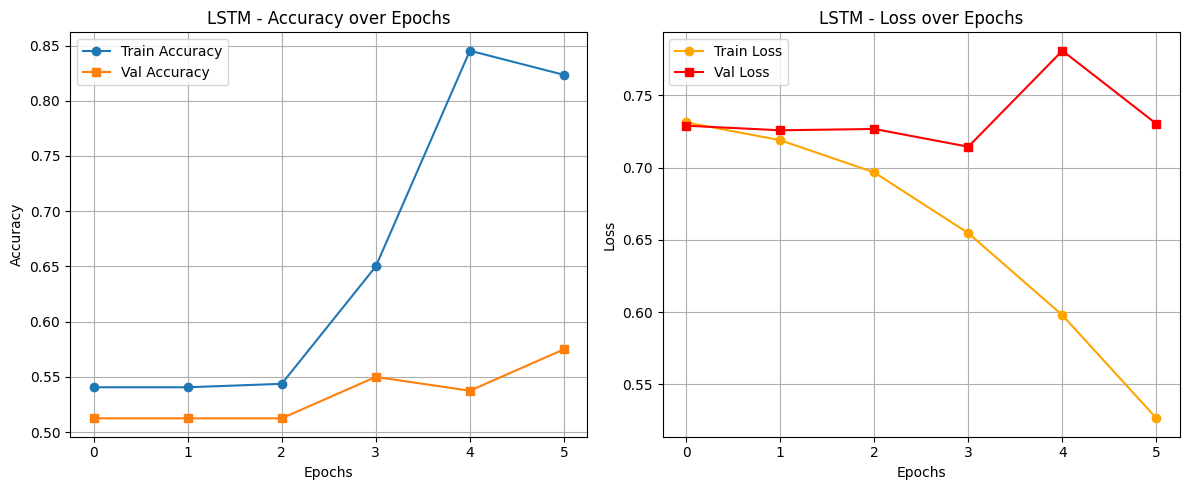

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Validation Accuracy over Epochs ---
axes[0].plot(history_lstm.history['accuracy'],     label='Train Accuracy', marker='o')
axes[0].plot(history_lstm.history['val_accuracy'], label='Val Accuracy',   marker='s')
axes[0].set_title('LSTM - Accuracy over Epochs')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# --- Plot 2: Loss over Epochs ---
axes[1].plot(history_lstm.history['loss'],     label='Train Loss', marker='o', color='orange')
axes[1].plot(history_lstm.history['val_loss'], label='Val Loss',   marker='s', color='red')
axes[1].set_title('LSTM - Loss over Epochs')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()